## CODE TAO DATA

In [7]:
import pandas as pd
from backtesting import Backtest, Strategy
import math
from vnstock3 import Vnstock
import talib as ta
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import datetime as dt

RSI_PERIOD = 14
RSI_OVERSOLD = 30
OBV_PERIOD = 5

def calculate_first_mondays(dates):
    if not isinstance(dates, pd.DatetimeIndex):
        dates = pd.DatetimeIndex(dates)
    dates_series = pd.Series(dates, index=dates)
    mondays = dates_series[dates_series.dt.dayofweek == 0]
    first_mondays = mondays.groupby([mondays.dt.year, mondays.dt.month]).first()
    return set(first_mondays)
    
class DCA(Strategy):
    average_monthly_income_vnd = 1000
    investment_percentage = 0.10  
    fund = 0

    def init(self):
        close = self.data.Close.astype(float)  
        volume = self.data.Volume.astype(float)  

        # Calculate RSI and OBV
        self.rsi = self.I(ta.RSI, close, timeperiod=RSI_PERIOD)
        self.obv = self.I(ta.OBV, close, volume)
        self.obv_slope = self.I(pd.Series(self.obv).diff, periods=OBV_PERIOD)
        self.previous_rsi = self.I(pd.Series(self.rsi).shift, 1)
        self.first_mondays = calculate_first_mondays(self.data.index)

    def next(self):
        today = self.data.index[-1]
        self.data.Close[-1] = self.data.Close[-1] / 10
        if today in self.first_mondays:
            self.fund += self.average_monthly_income_vnd * self.investment_percentage

        # Check for buy signal: rsi cắt và obv dương
        if (self.rsi[-1] > RSI_OVERSOLD and self.obv_slope[-1] > 0):
            # if (self.rsi[-1] > RSI_OVERSOLD and self.obv_slope[-1] > 0):
            share_price = self.data.Close[-1]
            shares_to_buy = self.fund // share_price
            shares_to_buy = (shares_to_buy // 100) * 100
            if shares_to_buy > 0:
                self.buy(size=shares_to_buy)
                self.fund -= share_price * shares_to_buy
                

In [8]:
def run_backtest(stock_symbol, start_date, end_date):
    # Fetch stock data
    stock_data = Vnstock().stock(symbol=stock_symbol, source='VCI').quote.history(start=start_date, end=end_date)
    stock_data = stock_data.rename(columns={"open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"})
    stock_data.set_index('time', inplace=True)
    stock_data.index = pd.to_datetime(stock_data.index)
    bt = Backtest(
        stock_data,
        DCA,
        trade_on_close=True,
    )
    stats = bt.run()
    #bt.plot(filename=f'{stock_symbol}')
    # Calculate investment details
    trades = stats["_trades"]
    price_paid = trades["Size"] * trades["EntryPrice"]
    total_invested = price_paid.sum()

    current_shares = trades["Size"].sum()
    current_equity = current_shares * stock_data.Close.iloc[-1]
    return {
        'stock_symbol': stock_symbol,
        'total investment': total_invested,
        'current shares': current_shares,
        'current_equity': current_equity,
        'ror': ((current_equity - total_invested) / total_invested) * 100
    }
stock_symbols = ['FPT', 'MWG', 'E1VFVN30']
date_start = '2019-01-01'
date_end = ['2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', '2024-01-04']
dict_symbol = {}
for symbol in stock_symbols:
    for date in date_end:
        # Convert date string to datetime object to extract the year
        date_obj = datetime.strptime(date, '%Y-%m-%d')
        key = f'{symbol}_{date_obj.year}'
        # Run the backtest for each stock symbol and date range
        dict_symbol[key] = run_backtest(symbol, start_date=date_start, end_date=date)

dict_symbol

2024-10-26 18:09:19,106 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 18:09:19,610 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 18:09:19,984 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 18:09:20,438 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 18:09:20,862 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 18:09:21,316 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 18:09:21,621 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 18:09:21,967 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yế

{'FPT_2020': {'stock_symbol': 'FPT',
  'total investment': 1011.5,
  'current shares': 500,
  'current_equity': 1242.5000000000002,
  'ror': 22.837370242214554},
 'FPT_2021': {'stock_symbol': 'FPT',
  'total investment': 2220.8,
  'current shares': 1000,
  'current_equity': 3014.9999999999995,
  'ror': 35.76188760806913},
 'FPT_2022': {'stock_symbol': 'FPT',
  'total investment': 3195.2000000000003,
  'current shares': 1200,
  'current_equity': 6684.0,
  'ror': 109.18878317476212},
 'FPT_2023': {'stock_symbol': 'FPT',
  'total investment': 4373.3,
  'current shares': 1400,
  'current_equity': 7898.8,
  'ror': 80.6141815105298},
 'FPT_2024': {'stock_symbol': 'FPT',
  'total investment': 5764.4,
  'current shares': 1600,
  'current_equity': 13430.4,
  'ror': 132.98868919575327},
 'MWG_2020': {'stock_symbol': 'MWG',
  'total investment': 966.0999999999999,
  'current shares': 300,
  'current_equity': 1094.1,
  'ror': 13.249146051133422},
 'MWG_2021': {'stock_symbol': 'MWG',
  'total inves

In [9]:
import pandas as pd

# Given data dictionary
data = dict_symbol
# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index')
df['year'] = df.index.str[-4:].astype(int)

## VISUAL

<Axes: xlabel='year', ylabel='ror'>

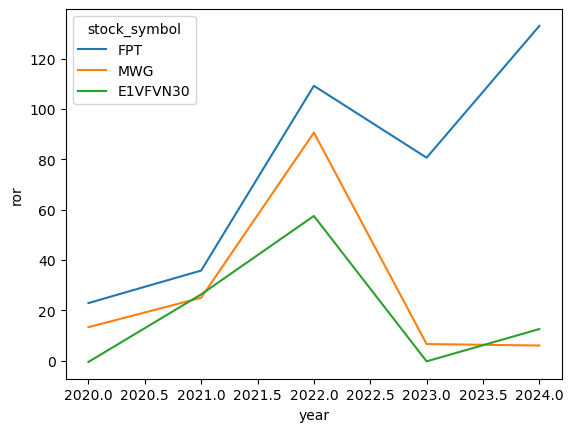

In [10]:
sns.lineplot(data=df, x='year', y='ror', hue='stock_symbol')

In [11]:
data_df = {
    'index': ['FPT_2020', 'FPT_2021', 'FPT_2022', 'FPT_2023', 'FPT_2024',
              'MWG_2020', 'MWG_2021', 'MWG_2022', 'MWG_2023', 'MWG_2024',
              'E1VFVN30_2020', 'E1VFVN30_2021', 'E1VFVN30_2022', 'E1VFVN30_2023', 'E1VFVN30_2024'],
    'stock_symbol': ['FPT', 'FPT', 'FPT', 'FPT', 'FPT', 
                     'MWG', 'MWG', 'MWG', 'MWG', 'MWG', 
                     'E1VFVN30', 'E1VFVN30', 'E1VFVN30', 'E1VFVN30', 'E1VFVN30'],
    'total_investment': [1011.5, 2220.8, 3195.2, 4373.3, 5764.4, 
                         966.1, 2160.8, 3133.1, 4352.7, 5662.5, 
                         1039.0, 2280.4, 3445.0, 4694.9, 5850.9],
    'current_shares': [500, 1000, 1200, 1400, 1600, 
                       300, 700, 900, 1100, 1400, 
                       700, 1600, 2100, 2700, 3300],
    'current_equity': [1242.5, 3015.0, 6684.0, 7898.8, 13430.4, 
                       1094.1, 2699.9, 5970.6, 4637.6, 6000.4, 
                       1033.2, 2880.0, 5424.3, 4679.1, 6583.5],
    'ror': [22.84, 35.76, 109.19, 80.61, 132.99, 
            13.25, 24.95, 90.57, 6.55, 5.97, 
            -0.56, 26.29, 57.45, -0.34, 12.52],
    'year': [2020, 2021, 2022, 2023, 2024, 
             2020, 2021, 2022, 2023, 2024, 
             2020, 2021, 2022, 2023, 2024]
}